In [29]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict,Literal
from pydantic import BaseModel,Field
from dotenv import load_dotenv

In [30]:
load_dotenv()

llmModel = ChatOpenAI(
   model="gpt-4o-mini"
)

In [31]:
class ReviewState(TypedDict):
    review:str
    sentiment:str
    diagnosis:dict
    response:str

class SentimentSchema(BaseModel):
    sentiment:Literal["positive","negitive"] = Field(description="Sentiment about the reviews")

class DiagnosisSchema(BaseModel):
    issueType:Literal["App","Product","UX","Performance","Support","Other"]=Field(description="Type of the issue")
    tone:Literal["angry","frustrated","Calm","Happy","disappointed"] = Field(description="emotions of the user from the review")
    urgency:Literal["low","medium","High"] = Field(description="How urgent /critical is the issye")



In [32]:
sentimentModel = llmModel.with_structured_output(SentimentSchema)
diagnosisModel = llmModel.with_structured_output(DiagnosisSchema)

In [33]:
def get_sentiment(state:ReviewState)->dict:
    print(f'[get_sentiment]')
    review_prompt = f'Get the sentiment based for the user review and review is: {state["review"]}'
    model_response = sentimentModel.invoke(review_prompt)
    return {'sentiment':model_response.sentiment}

In [34]:
def perform_diagnosis(state:ReviewState)->dict:
    print(f'[perform_diagnosis]')
    diagnosis_Prompt = f'Identify the issue type,tone and urgency of review and review is:  {state["review"]}'
    model_response = diagnosisModel.invoke(diagnosis_Prompt)
    disnosisDetails={
        'issueType':model_response.issueType,
        'tone':model_response.tone,
        'urgency':model_response.urgency
    }
    return {'diagnosis':disnosisDetails}

In [35]:
def check_and_return_route_for_sentiment(state:ReviewState)->Literal["generate_positive_response","perform_diagnosis"]:
    print(f'[check_and_return_route_for_sentiment]')
    if state["sentiment"]=="positive":
        return "generate_positive_response"
    else:
        return "perform_diagnosis"
    

In [36]:
def generate_positive_response(state:ReviewState)->dict:
    print(f'[generate_positive_response]')
    prompt = f'generate the thank you message for positive feedback when review provideded by user is:  {state["review"]}'
    model_response = llmModel.invoke(prompt)
    json_response = getattr(model_response, "content", None) or model_response    
    return {'response':json_response}

In [37]:
def generate_negative_response(state:ReviewState)->dict:
    print(f'[generate_negative_response]')
    diagnosis_details = state["diagnosis"]
    issueType= diagnosis_details["issueType"]
    tone= diagnosis_details["tone"]    
    urgency= diagnosis_details["urgency"]
    diagnosis_Prompt = f"""
    generate the response message when review is negative provided by user with with following details
    review provideded by user is:  {state["review"]}'
    issue type: {issueType}
    tone of user: {tone}
    urgency of issue: {urgency}
    """
    model_response = llmModel.invoke(diagnosis_Prompt)
    json_response = getattr(model_response, "content", None) or model_response    
    return {'response':json_response}

In [38]:
graph = StateGraph(ReviewState)
graph.add_node("get_sentiment",get_sentiment)
graph.add_node("perform_diagnosis",perform_diagnosis)
graph.add_node("generate_negative_response",generate_negative_response)
graph.add_node("generate_positive_response",generate_positive_response)

graph.add_edge(START,"get_sentiment")
graph.add_conditional_edges("get_sentiment",check_and_return_route_for_sentiment)
graph.add_edge("perform_diagnosis","generate_negative_response")
graph.add_edge("generate_positive_response",END)
graph.add_edge("generate_negative_response",END)

workflow = graph.compile()

In [39]:
# Postive
# initial_state = {"review":"The app is easy to use. It works fast and has a simple design."}
# initial_state = {"review":"The product is good and works as expected. The quality is also nice."}

# Negative
# initial_state = {"review":"The app is slow and sometimes stops working. It needs improvement."}
initial_state = {"review":"The product quality is not good. It did not work properly after some use."}
response = workflow.invoke(initial_state)
print(response)

[get_sentiment]
[check_and_return_route_for_sentiment]
[perform_diagnosis]
[generate_negative_response]
{'review': 'The product quality is not good. It did not work properly after some use.', 'sentiment': 'negitive', 'diagnosis': {'issueType': 'Product', 'tone': 'disappointed', 'urgency': 'medium'}, 'response': "Subject: We're Here to Help: Addressing Your Concerns\n\nDear [User's Name],\n\nThank you for your feedback regarding your recent experience with our product. We are genuinely sorry to hear that the quality did not meet your expectations and that it did not work properly after some use. Your disappointment is understandable, and we appreciate you bringing this to our attention.\n\nWe take product quality seriously, and your feedback is invaluable in helping us improve. To assist you further, we would like to offer you a resolution. Please provide us with some additional details about the issue you encountered, and we will do our best to address it promptly.\n\nWe appreciate you

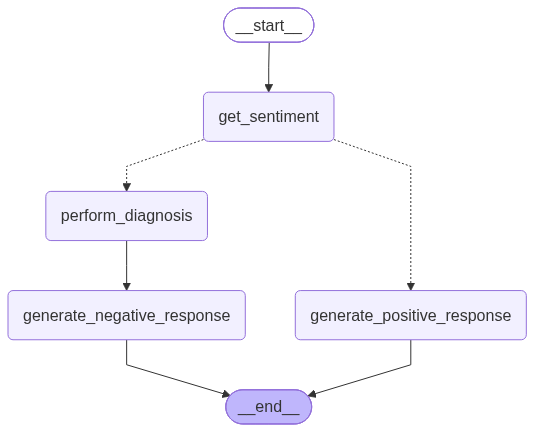

In [40]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())